In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df_full=pd.read_csv("../data/RELIANCE_features_v2.csv", index_col=0, parse_dates=True)

X_Test=pd.read_csv("../data/X_test.csv", index_col=0, parse_dates=True)
Y_Test=pd.read_csv("../data/Y_test.csv", index_col=0, parse_dates=True).squeeze() #.squeeze convert the Date and target row coloumn format to a series format where Data and target are on entry only



from xgboost import XGBClassifier

import pickle
with open("../data/model.pkl", "rb") as f:
    model=pickle.load(f)

print("MODEL LOADED")
print(f"Test Period: {X_Test.index[0]} to {X_Test.index[-1]}")






MODEL LOADED
Test Period: 2023-01-11 00:00:00 to 2023-12-29 00:00:00


In [19]:
y_pred = model.predict(X_Test)
y_prob = model.predict_proba(X_Test)[:, 1] #gets the probability of getting 1

#build a results dataframe
results=pd.DataFrame(index=X_Test.index)
results["Actual"]=Y_Test.values
results["Predicted"]=y_pred
results["Probability"]=y_prob
results["Close"]= df_full.loc[X_Test.index, "Close"]

print(results.head(20))
print(f"Predicted UP: {(results['Predicted']==1).sum()}")
print(f"Predicted DOWN: {(results['Predicted']==0).sum()}")




            Actual  Predicted  Probability        Close
2023-01-11       0          0     0.406797  1153.179077
2023-01-12       1          0     0.297726  1128.276978
2023-01-13       0          0     0.359467  1126.451172
2023-01-16       0          0     0.410935  1115.723389
2023-01-17       0          0     0.386854  1131.563965
2023-01-18       0          0     0.343193  1129.692139
2023-01-19       0          0     0.345707  1128.482544
2023-01-20       0          0     0.425608  1115.061523
2023-01-23       0          0     0.421591  1109.423706
2023-01-24       0          0     0.385046  1102.873047
2023-01-25       0          1     0.644989  1087.625977
2023-01-27       0          1     0.744947  1066.992432
2023-01-30       0          1     0.721075  1077.218018
2023-01-31       0          1     0.684755  1074.524414
2023-02-01       1          1     0.695097  1068.156372
2023-02-02       1          1     0.705838  1062.244751
2023-02-03       1          1     0.731628  1063

What does predict_proba() give you that predict() doesn't? 
predict_proba() returns probability for both classes — column 0 is probability of DOWN, column 1 is probability of UP. So [:, 1] means "give me the second column for all rows" — the UP probability


What does [:, 1] mean in y_prob = model.predict_proba(X_test)[:, 1]? Means the probability of getting a 1 according to model 

In [ ]:
from IPython.display import display



def backtest_strategy(results, initial_capital=100000, transaction_cost=0.001, threshold=0.5):
    """We are simply doing these steps: 
        -If currently not holding and model predicts UP, we buy
        -If holding and model predicts DOWN, we sell
        -A simple transaction cost on every share bought and sold
        -We have kept the proability threshold to be .5 here
    
    """

    capital= initial_capital
    position=0 # number of shares held
    portfolio=[] #closing value of portfolio each day
    cash=[]
    stock_value=[]
    buy=True    #track if we can buy right now or not


    for i in range(len(results)):

        price=results["Close"].iloc[i]
        prob=results["Probability"].iloc[i]

        if (buy and prob>=threshold):
            shares_bought=capital/(price*(1+transaction_cost))
            capital=0
            position=shares_bought
            buy=False

        elif (not buy and prob<threshold):
            money_got=position*(price*(1-transaction_cost))
            capital=money_got
            position=0
            buy=True

        total_value=position*price+capital
        portfolio.append(total_value)
        cash.append(capital)
        stock_value.append(position*price)
    results["CashInHand"]=cash
    results["Stock_Value"]=stock_value
    results["Strategy_Value"]= portfolio
    return results


backtest_strategy(results, 100000, 0.001, 0.5)

#pd.set_option('display.max_rows', None)
display(results)

# one major assumption that we are taking in this project is that, Our model predicts the target taking into account the close of current day
# and we are using that signal to buy on the same day, but the market is already closed we cannot make a trade now,
# so we assume that we will make this trade on next day as soon as market opens
# this is a simplifying assumption that we have taken








What does transaction_cost=0.001 mean? What percentage is that? 0.1% of share cost 

Why do we track in_trade as a boolean? to see if we can buy in the current state or not, maybe we get a buy signal but all my cash is already invested I cannot buy today. 

What happens to our capital when we're not in a trade? nothing it sits with us in form of cash


Why do we subtract transaction cost on both buy and sell? because it is a transaction cost and not a sell or buy cost, we have to pay it everytime we buy or sell.

In [ ]:
#buy on day 1 and never sell again or make a trade again sell on last day

def buy_and_hold(results,initial_capital=100000, transaction_cost=0.001):
    open_price=results["Close"].iloc[0];
    shares_bought=initial_capital/(open_price*(1+transaction_cost))
    results["BuyHold_Value"]=shares_bought*results["Close"]

    last_price=results["Close"].iloc[-1];
    sell_money=shares_bought*(last_price*(1-transaction_cost))
    
    results.loc[results.index[-1], "BuyHold_Value"]=sell_money

    return results

buy_and_hold(results,100000,0.001)

display(results)

# in the results I noticed buyhold value is same on day 1 as on 2023-01-25 when we first bought our shares according to model, how can it be same?
# it is same because, value=shares*(price)
#                     shares=capital/price(1+tc);
#                     value=capital*price/price*(1+tc)= capital/(1+tc) thus givnig the same value




Why is buy and hold a fair benchmark to compare against?

The real reason buy and hold is a fair benchmark is: it requires zero skill, zero effort, zero transaction costs, and historically markets trend upward over long periods. So it's the minimum bar any active strategy must beat to justify its complexity.



Can you think of a situation where almost no active strategy beats buy and hold? yes, if there is a pure upward trend in the close price, then maybe our model buys and sells in between the period multiple times losing money to transaction costs, however at the end buy and hold will win in this


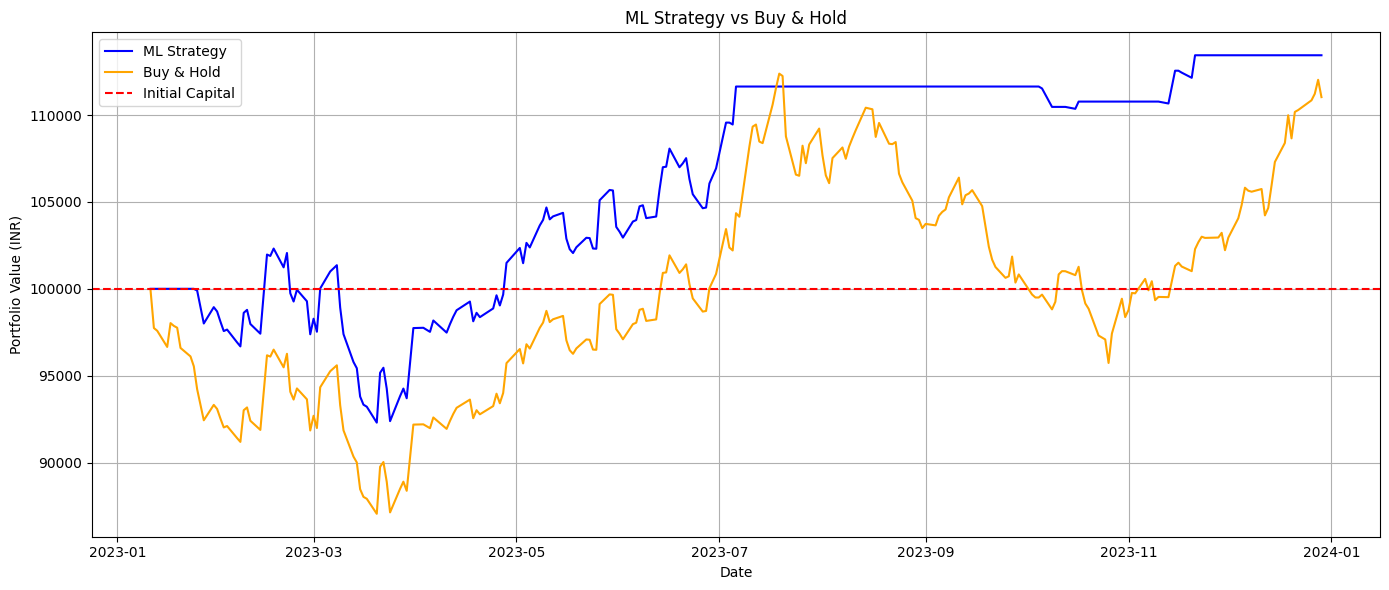

ML Strategy Final Value:  INR 113,443
Buy & Hold Final Value:   INR 111,034
ML Strategy Return:       13.44%
Buy & Hold Return:        11.03%


In [35]:
initial_capital = 100000  # INR 1 lakh

results = backtest_strategy(results, 
                             initial_capital=initial_capital,
                             transaction_cost=0.001,
                             threshold=0.5)

results = buy_and_hold(results, 
                        initial_capital=initial_capital)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(results.index, results["Strategy_Value"], 
         label="ML Strategy", color="blue", linewidth=1.5)
plt.plot(results.index, results["BuyHold_Value"], 
         label="Buy & Hold", color="orange", linewidth=1.5)
plt.axhline(initial_capital, color="red", 
            linestyle="--", label="Initial Capital")
plt.title("ML Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final values
strategy_final  = results["Strategy_Value"].iloc[-1]
buyhold_final   = results["BuyHold_Value"].iloc[-1]
strategy_return = (strategy_final - initial_capital) / initial_capital * 100
buyhold_return  = (buyhold_final - initial_capital) / initial_capital * 100

print(f"ML Strategy Final Value:  INR {strategy_final:,.0f}")
print(f"Buy & Hold Final Value:   INR {buyhold_final:,.0f}")
print(f"ML Strategy Return:       {strategy_return:.2f}%")
print(f"Buy & Hold Return:        {buyhold_return:.2f}%")

In [ ]:
def calc_metrics(portfolio_value, label="Stratergy"):
    values=pd.Series(portfolio_value)
    returns=values.pct_change().dropna()


    sharpe=(returns.mean()/returns.std()) * np.sqrt(252)

    rolling_max=values.cummax()
    drawdown=(values-rolling_max)/rolling_max
    max_dd=drawdown.min()

    print(f"\n{label}:")
    print(f" Sharpe Ratio: {sharpe:.4f}")
    print(f" Max_DD: {max_dd*100:.4f}")

    return sharpe, max_dd

strat_sharpe, strat_dd = calc_metrics(
    results["Strategy_Value"], "ML Strategy")
bh_sharpe, bh_dd       = calc_metrics(
    results["BuyHold_Value"], "Buy & Hold")

results.to_csv("../data/results.csv")


ML Strategy:
 Sharpe Ratio: 1.1205
 Max_DD: -9.7922

Buy & Hold:
 Sharpe Ratio: 0.7362
 Max_DD: -14.8173


Sharpe Ratio measures return per unit of risk:
Sharpe = (Mean Daily Return - Risk Free Rate) / Std of Daily Returns

- Sharpe Ratio < 1 : Poor risk-adjusted performance
- Sharpe Ratio between 1 and 2 : Acceptable performance
- Sharpe Ratio between 2 and 3 : Very good performance
- Sharpe Ratio > 3 : Excellent performance




Max Drawdown measures the worst peak to trough loss:
Max Drawdown = (Trough Value - Peak Value) / Peak Value

- A smaller magnitude drawdown indicates better capital preservation.
- A large drawdown suggests the strategy may expose investors to significant temporary losses.
- Drawdown is often considered alongside returns because two strategies may achieve similar returns while exposing investors to vastly different levels of risk.



If your Sharpe ratio is 1.2, what does that mean in plain words? 
It means that overall we had a decent performance. Sharpe of 1.2 means for every unit of risk you took, you earned 1.2 units of return. 


If max drawdown is -23%, what does that mean? 
It means that at some points we faced a maximum dip from peak to lowest by 23% say peak was 100 then we saw 77 at some point. which can be scary to people. 

Which is better — higher Sharpe or lower Sharpe? Higher drawdown or lower drawdown? 
A higher sharpe is better, a DD closer to 0 is better as we see less dips 